In [1]:
# Spark Session
from pyspark.sql import SparkSession

spark = (
    SparkSession
    .builder
    .appName("Spark Memory Management")
    .master("spark://4619b568af8b:7077")
    .config("spark.cores.max", 8)
    .config("spark.executor.cores", 4)
    .config("spark.executor.memory", "512MB")
    .getOrCreate()
)

spark

In [2]:
# JVM On-Heap Usable memory (89% of executor memory)
512 * 0.89

455.68

In [3]:
# Subtracting Reserve Memory (300MB)
455.68 - 300

155.68

In [4]:
# Total Spark Memory (Unified Memory - Storage + Execution Memory) (60% default) spark.memory.fraction = 0.6
155.68 * 0.6

93.408

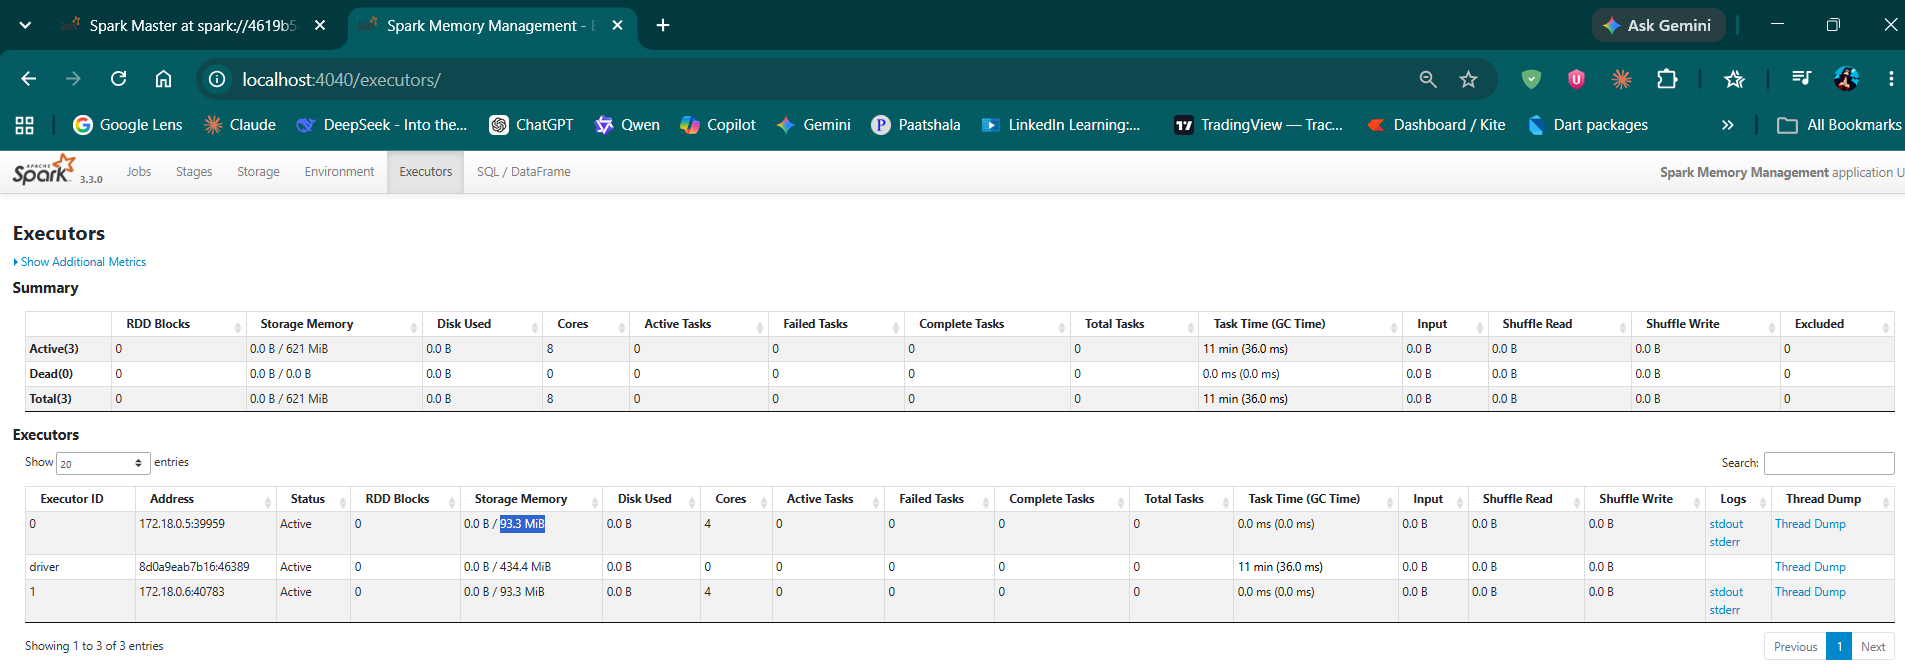

In [5]:
# User / Undefined Memory (Not controlled by Spark) (remaining 40% default)
155.68 * 0.4

62.272000000000006

In [6]:
# Storage Memory (spark.memory.storageFraction = 0.5)
93.408 * 0.5

46.704

In [7]:
# Execution Memory
93.408 * 0.5

46.704

In [8]:
# Execution Memory per core ( we have 4 core)
46.704 / 4

11.676

## Out Of Memory Error Demo

Below we'll see two ways of reading the **same text data** and running the same word-count logic.

- **1st attempt** — read the file as a single giant line → `explode` blows up → **OOM error**.
- **2nd attempt** — read the file as many small lines → `explode` is safe → **no error**.

The difference comes down to **how big each individual row is** when `explode` runs.

---

In [9]:
# Disable AQE and Broadcast join

spark.conf.set("spark.sql.adaptive.enabled", False)
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", False)
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)

In [10]:
%%sh
ls -ltrh /data/text/*

-rwxrwxrwx 1 root root 21M Jan 13  2025 /data/text/text_file_s.txt
-rwxrwxrwx 1 root root 11M Jan 13  2025 /data/text/text_file_singleline_xs.txt
-rwxrwxrwx 1 root root 11M Jan 13  2025 /data/text/text_file_xs.txt


In [ ]:
# Read file
df = spark.read.format("text").load("/data/text/text_file_singleline_xs.txt")

In [ ]:
# Cache data
df.cache().count()
# data is cached and we know the whole file is in a single line.thats why the output is 1.
# cache is by default memmory and disk deserialized.

1

#### ☝️ Notice the data skew

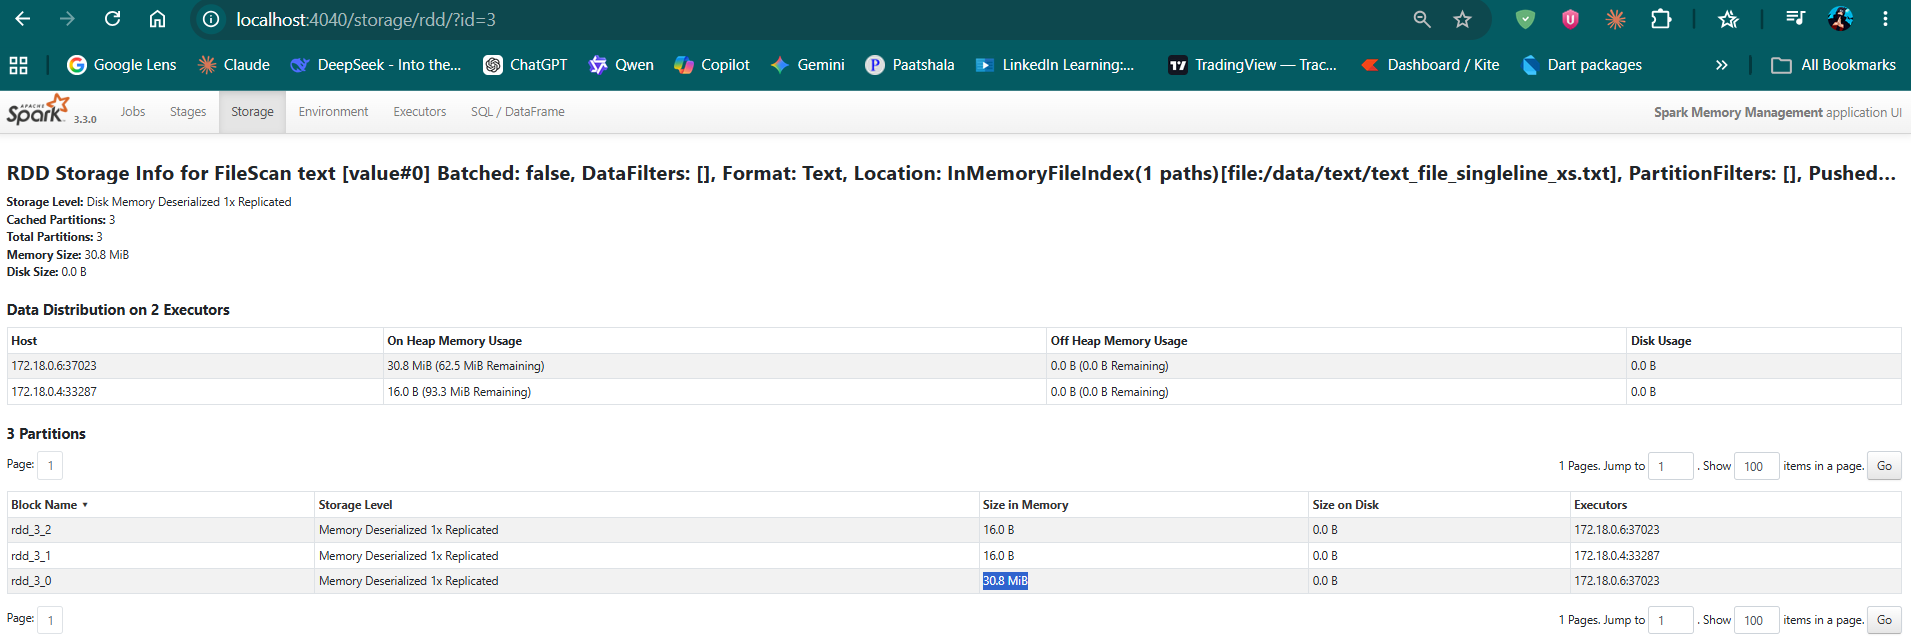

See — one partition is skewed.

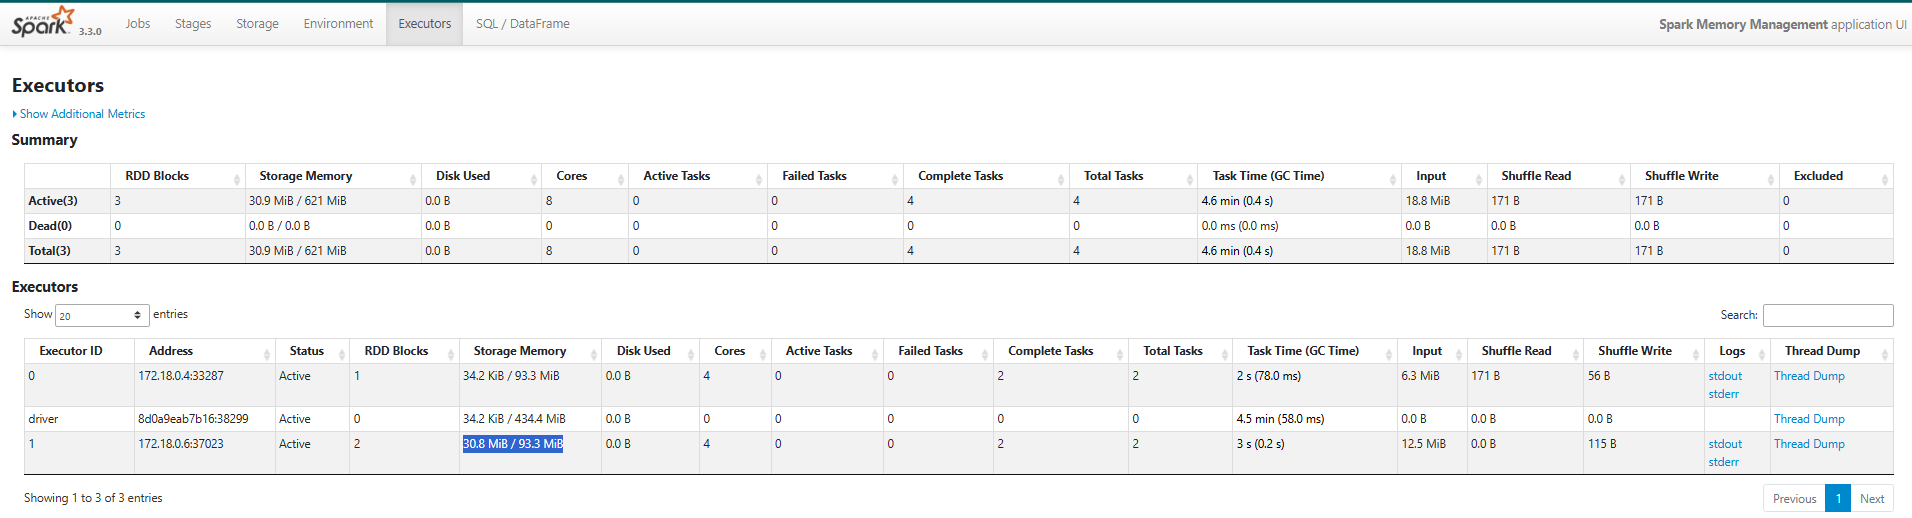

Out of the 93.3 MB total Spark Memory, 30.8 MB is consumed in 1 executor.

**Why?** Because the entire file is a **single line**. Spark read it into **one row** in **one partition**. So all 30 MB of text sits in a single record on a single executor — that's the skew.

This isn't an error *yet*. The data fits in memory. The crash happens **next**, when we `explode` that giant row.

---

In [13]:
df.printSchema()

root
 |-- value: string (nullable = true)



In [17]:
# Import the required PySpark SQL functions
from pyspark.sql.functions import lower, split, explode, count, lit

df_final = (
    df.withColumn("value", lower("value"))
    .withColumn("splitted_value", split("value", " "))
    
    # Example of what explode does:
    # If splitted_value is: ["PySpark", "is", "awesome"]
    # explode will turn it into 3 separate rows:
    # Row 1: "PySpark"
    # Row 2: "is"
    # Row 3: "awesome"
    .withColumn("exploded_val", explode("splitted_value")) 
    .drop("splitted_value", "value")
    # Group by the new 'exploded_val' column instead of the one you dropped
    .groupBy("exploded_val")
    # Move .alias("cnt") inside the .agg() parentheses
    .agg(count(lit(1)).alias("cnt"))
)



In [18]:
df_final.show()

Py4JJavaError: An error occurred while calling o93.showString.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 0 in stage 2.0 failed 4 times, most recent failure: Lost task 0.3 in stage 2.0 (TID 10) (172.18.0.6 executor 2): java.lang.OutOfMemoryError: GC overhead limit exceeded
	at java.lang.String.substring(String.java:1969)
	at java.lang.String.split(String.java:2374)
	at org.apache.spark.unsafe.types.UTF8String.split(UTF8String.java:1027)
	at org.apache.spark.unsafe.types.UTF8String.split(UTF8String.java:1003)
	at org.apache.spark.sql.catalyst.expressions.GeneratedClass$GeneratedIteratorForCodegenStage1.hashAgg_doAggregateWithKeys_0$(Unknown Source)
	at org.apache.spark.sql.catalyst.expressions.GeneratedClass$GeneratedIteratorForCodegenStage1.processNext(Unknown Source)
	at org.apache.spark.sql.execution.BufferedRowIterator.hasNext(BufferedRowIterator.java:43)
	at org.apache.spark.sql.execution.WholeStageCodegenExec$$anon$1.hasNext(WholeStageCodegenExec.sca

#### ☝️ Why did this crash? — Understanding the OOM error

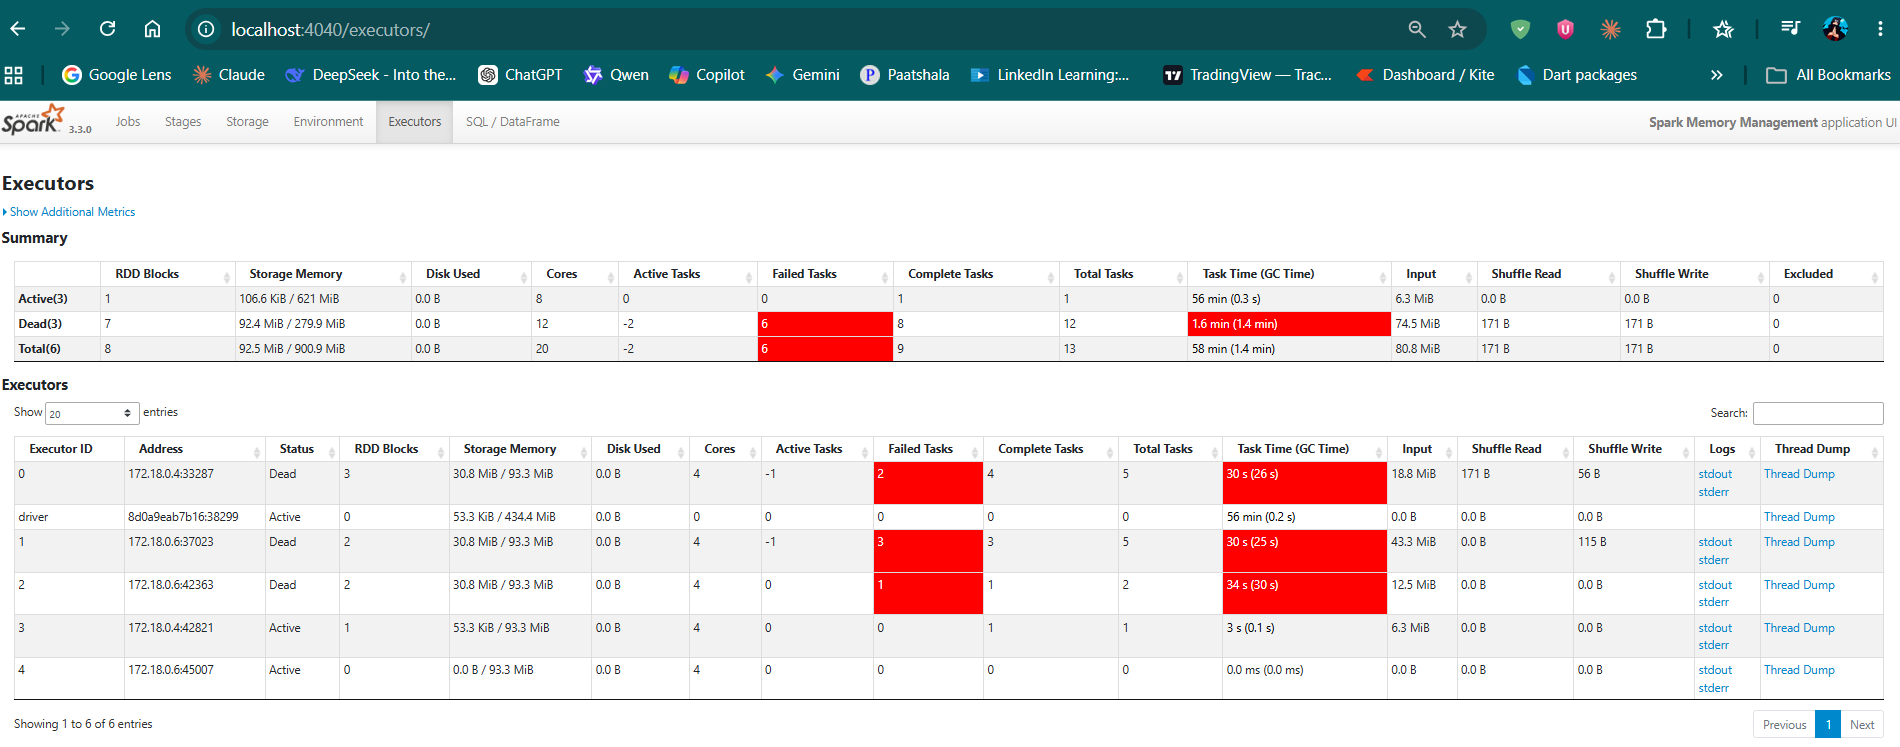
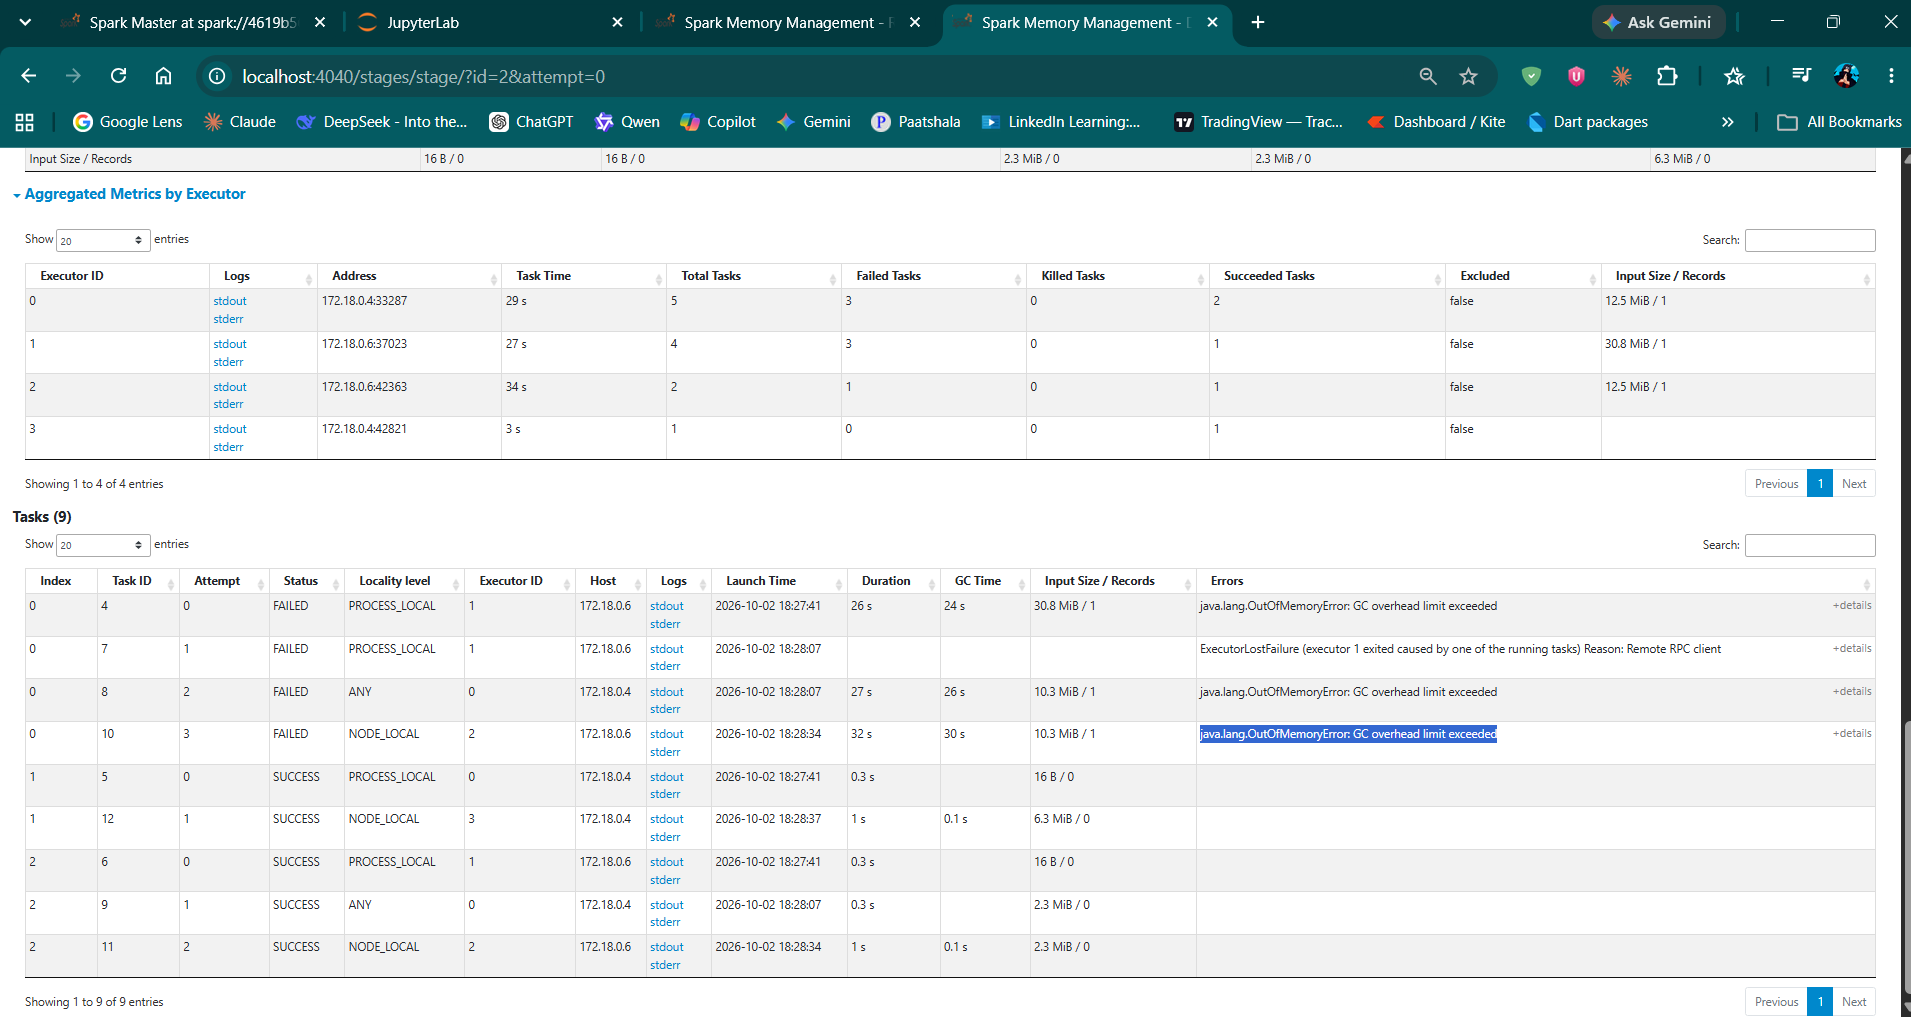

The file `text_file_singleline_xs.txt` stores the **entire text in a single line**.

Here's what happened step by step:

1. **`spark.read`** loaded that single line as **1 row** in the DataFrame — roughly 30 MB of text in one cell.
2. **`split("value", " ")`** turned that 30 MB string into an **array of hundreds of thousands of words** — but it's still **1 row**. The array lives inside that same single record.
3. **`explode("splitted_value")`** tried to expand that one row into **hundreds of thousands of separate rows** — all at once, all inside the same task's memory.

The problem: the executor only has ~11.6 MB of Execution Memory per core (46.7 MB ÷ 4 cores). But `explode` needs to hold the original 30 MB row **plus** generate all the exploded output rows in that same memory. That's far more than 11.6 MB → **Out Of Memory**.

Think of it like tearing a 1000-page book into individual pages. If your desk can only hold 50 pages at a time, and you have to rip all 1000 pages at once before you can file any of them — your desk overflows and everything falls on the floor.

**Key point:** The issue isn't the total data size — it's that a **single record** is so large that processing it exceeds the memory available to one core.

---

### ✅ The fix: Read the same data as multiple small lines

Below, we read `text_file_xs.txt` instead — same words, but stored as **many separate lines** (one paragraph per line).

Now each row is tiny (a few hundred bytes), so `explode` on any single row produces only a handful of words. No single task's memory is overwhelmed → **no OOM error**.

| | 1st attempt (single line file) | 2nd attempt (multi-line file) |
|---|---|---|
| **File** | `text_file_singleline_xs.txt` | `text_file_xs.txt` |
| **Rows after read** | 1 giant row (~30 MB) | Many small rows (few KB each) |
| **After `split`** | 1 row with a massive array | Many rows with small arrays |
| **After `explode`** | 1 task must produce 100K+ rows from 1 record → OOM | Each task produces a few rows per record → fits easily |
| **Result** | ❌ OOM Error | ✅ Works fine |

**Takeaway:** When using `explode`, always make sure no **single row** contains a massive amount of data. If your source file is one giant line, split it into multiple lines before loading — or use `spark.read.text()` with `lineSep` options to control how lines are split.

---

In [20]:
# so rather read it in a single line read it in multi line
# Read file
df = spark.read.format("text").load("/data/text/text_file_xs.txt")
df.show()

+--------------------+
|               value|
+--------------------+
|Quisquam dolor ut...|
|                    |
|Est etincidunt do...|
|                    |
|Neque sed amet do...|
|                    |
|Dolore dolorem la...|
|                    |
|Velit voluptatem ...|
|                    |
|Sit ut voluptatem...|
|                    |
|Est etincidunt do...|
|                    |
|Neque sed amet do...|
|                    |
|Dolore dolorem la...|
|                    |
|Velit voluptatem ...|
|                    |
+--------------------+
only showing top 20 rows



In [21]:
df.cache().count()

60001

In [22]:
df.printSchema()

root
 |-- value: string (nullable = true)



In [23]:
# Import the required PySpark SQL functions
from pyspark.sql.functions import lower, split, explode, count, lit

df_final = (
    df.withColumn("value", lower("value"))
    .withColumn("splitted_value", split("value", " "))
    
    # Example of what explode does:
    # If splitted_value is: ["PySpark", "is", "awesome"]
    # explode will turn it into 3 separate rows:
    # Row 1: "PySpark"
    # Row 2: "is"
    # Row 3: "awesome"
    .withColumn("exploded_val", explode("splitted_value")) 
    .drop("splitted_value", "value")
    # Group by the new 'exploded_val' column instead of the one you dropped
    .groupBy("exploded_val")
    # Move .alias("cnt") inside the .agg() parentheses
    .agg(count(lit(1)).alias("cnt"))
)

In [24]:
df_final.show()

+------------+-----+
|exploded_val|  cnt|
+------------+-----+
|     tempora|30000|
|consectetur.|12000|
|      ipsum.|12000|
|        non.| 6000|
|       velit|66000|
|   adipisci.| 6000|
|         non|66000|
|     dolore.|12000|
|         sit|60000|
| consectetur|42000|
|    quisquam|54001|
|    numquam.|12000|
|     magnam.|18000|
|     numquam|30000|
|      magnam|42000|
|     quiquia|66000|
|    aliquam.|12000|
|       dolor|54000|
|       eius.|12000|
|       neque|36000|
+------------+-----+
only showing top 20 rows



In [ ]:
# Read file
# df = spark.read.format("text").option("wholetext", True).load("/data/text/text_file_xs.txt")

# WARNING: .option("wholetext", True) reads the ENTIRE file as a single row,
# even if the file has multiple lines. This means even a multi-line file
# will behave like the single-line case — one giant row that can cause
# an OOM error when you explode it.
